In [1]:
import json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from config import TrainConfig


In [2]:
# Graph + ST-GCN with multi-person adjacency
COCO_EDGES = [
    (0, 1), (0, 2), (1, 3), (2, 4),
    (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
    (11, 12), (5, 11), (6, 12),
    (11, 13), (13, 15), (12, 14), (14, 16),
]

def build_multi_adjacency(num_persons: int, joints_per_person: int = 17):
    V = num_persons * joints_per_person
    A = torch.eye(V)
    # Intra-person edges (block-diagonal COCO skeleton)
    for p in range(num_persons):
        offset = p * joints_per_person
        for i, j in COCO_EDGES:
            A[offset + i, offset + j] = 1
            A[offset + j, offset + i] = 1
    # Inter-person edges: connect hip centers across persons (nodes 11 and 12)
    hips = [11, 12]
    for pa in range(num_persons):
        for pb in range(pa + 1, num_persons):
            oa = pa * joints_per_person
            ob = pb * joints_per_person
            for h in hips:
                A[oa + h, ob + h] = 1
                A[ob + h, oa + h] = 1
    D = torch.diag(1.0 / torch.clamp(A.sum(dim=1), min=1.0))
    return D @ A

class GraphConv(nn.Module):
    def __init__(self, in_channels, out_channels, A, stride=1, residual=True, dropout=0.0):
        super().__init__()
        self.A = nn.Parameter(A, requires_grad=False)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=(9, 1), stride=(stride, 1), padding=(4, 0))
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.drop = nn.Dropout(dropout)
        if not residual:
            self.residual = lambda x: 0
        elif in_channels == out_channels and stride == 1:
            self.residual = lambda x: x
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride, 1)),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        res = self.residual(x)
        x = torch.einsum("nctv,vw->nctw", x, self.A)
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.drop(x)
        return x + res

class STGCN(nn.Module):
    def __init__(self, num_classes: int, in_channels: int, graph_nodes: int, num_persons: int, base_channels: int = 64, dropout: float = 0.5):
        super().__init__()
        A = build_multi_adjacency(num_persons=num_persons, joints_per_person=graph_nodes // num_persons)
        self.register_buffer("A", A)
        channels = [base_channels, base_channels, base_channels, 2 * base_channels, 2 * base_channels, 4 * base_channels]
        strides = [1, 1, 1, 2, 1, 2]
        layers = []
        c_in = in_channels
        for c_out, s in zip(channels, strides):
            layers.append(GraphConv(c_in, c_out, self.A, stride=s, residual=True, dropout=dropout))
            c_in = c_out
        self.stgcn = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(channels[-1], num_classes)

    def forward(self, x):
        x = self.stgcn(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [3]:
class RWF2000SkeletonsMP(Dataset):
    def __init__(self, root: str | Path, split: str = "train", key: str = "skeletons", max_persons: int = 3):
        self.root = Path(root)
        self.split = split
        self.key = key
        self.max_persons = max_persons
        split_dir = self.root / split
        if not split_dir.exists():
            raise FileNotFoundError(f"Missing split directory: {split_dir}")
        self.samples: list[tuple[Path, int, int]] = []
        for label_name, label in [("Fight", 1), ("NonFight", 0)]:
            label_dir = split_dir / label_name
            if not label_dir.exists():
                continue
            for npz_path in sorted(label_dir.glob("*.npz")):
                with np.load(npz_path) as data:
                    n = data[self.key].shape[0]
                for idx in range(n):
                    self.samples.append((npz_path, label, idx))
        if not self.samples:
            raise RuntimeError(f"No skeleton files found under {split_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index: int):
        npz_path, label, window_idx = self.samples[index]
        with np.load(npz_path) as data:
            window = data[self.key][window_idx]  # (P, T, V, C)
            label_arr = data.get("labels")
            if label_arr is not None:
                label = int(label_arr[window_idx])

        P, T, V, C = window.shape
        target_p = self.max_persons
        if P >= target_p:
            window = window[:target_p]
        else:
            pad = np.zeros((target_p - P, T, V, C), dtype=window.dtype)
            window = np.concatenate([window, pad], axis=0)

        # to (P, C, T, V) then flatten persons into node dimension: (C, T, P*V)
        window = np.transpose(window, (0, 3, 1, 2))
        window = window.transpose(1, 2, 0, 3)  # (C, T, P, V)
        window = window.reshape(window.shape[0], window.shape[1], target_p * V)
        window = window.astype(np.float32)
        return torch.from_numpy(window), torch.tensor(label, dtype=torch.long)


In [4]:
# Paths and hyperparams
DATA_ROOT = Path("precomputed_skeletons")
MAX_PERSONS = 3
FEATURE_CHANNELS = 7
V_TOTAL = MAX_PERSONS * 17

cfg = TrainConfig()
cfg.batch_size = 32
cfg.max_epochs = 10
cfg.dropout = 0.2
cfg.joint_dropout = 0.0
cfg.lr = 3e-4
cfg.weight_decay = 1e-4

# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = 'mps'
print("Device:", DEVICE)

train_ds = RWF2000SkeletonsMP(DATA_ROOT, split="train", max_persons=MAX_PERSONS)
val_ds = RWF2000SkeletonsMP(DATA_ROOT, split="val", max_persons=MAX_PERSONS)
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.workers)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.workers)

x_probe, y_probe = next(iter(train_loader))
print("Probe shape (C, T, V_total):", x_probe.shape, "label:", int(y_probe[0]))


Device: mps
Probe shape (C, T, V_total): torch.Size([32, 7, 30, 51]) label: 0


In [5]:
base_channels = 64
model = STGCN(
    num_classes=cfg.num_classes,
    in_channels=FEATURE_CHANNELS,
    graph_nodes=V_TOTAL,
    num_persons=MAX_PERSONS,
    base_channels=base_channels,
    dropout=cfg.dropout,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optim = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=cfg.max_epochs)


In [6]:
from sklearn.metrics import f1_score, roc_auc_score
from torch.nn.utils import clip_grad_norm_

max_epochs = cfg.max_epochs
best_acc = 0.0
best_state = None

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "train_auc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "val_auc": [],
}

for epoch in range(max_epochs):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    preds_all, labels_all, probs_all = [], [], []
    pbar = tqdm(train_loader, desc=f"Train {epoch+1}/{max_epochs}")
    for X, y in pbar:
        X = X.to(DEVICE)
        y = y.to(DEVICE)
        if cfg.joint_dropout > 0:
            mask = (torch.rand_like(X[:, :1]) > cfg.joint_dropout).float()
            X = X * mask
        logits = model(X)
        loss = criterion(logits, y)
        optim.zero_grad()
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optim.step()
        bs = y.size(0)
        preds = logits.argmax(dim=1)
        probs = logits.softmax(dim=1)[:, 1]
        loss_sum += float(loss.item()) * bs
        total += bs
        correct += int((preds == y).sum().item())
        preds_all.append(preds.detach().cpu())
        labels_all.append(y.detach().cpu())
        probs_all.append(probs.detach().cpu())
        pbar.set_postfix(loss=loss_sum/max(1,total), acc=correct/max(1,total))

    train_loss = loss_sum / max(1, total)
    train_acc = correct / max(1, total)
    train_preds = torch.cat(preds_all).numpy()
    train_labels = torch.cat(labels_all).numpy()
    train_probs = torch.cat(probs_all).numpy()
    train_f1 = f1_score(train_labels, train_preds)
    train_auc = roc_auc_score(train_labels, train_probs)
    scheduler.step()

    model.eval()
    v_total, v_correct, v_loss_sum = 0, 0, 0.0
    v_preds, v_labels, v_probs = [], [], []
    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(DEVICE)
            y = y.to(DEVICE)
            logits = model(X)
            loss = criterion(logits, y)
            bs = y.size(0)
            preds = logits.argmax(dim=1)
            probs = logits.softmax(dim=1)[:, 1]
            v_loss_sum += float(loss.item()) * bs
            v_total += bs
            v_correct += int((preds == y).sum().item())
            v_preds.append(preds.cpu())
            v_labels.append(y.cpu())
            v_probs.append(probs.cpu())

    v_loss = v_loss_sum / max(1, v_total)
    v_acc = v_correct / max(1, v_total)
    v_preds_np = torch.cat(v_preds).numpy()
    v_labels_np = torch.cat(v_labels).numpy()
    v_probs_np = torch.cat(v_probs).numpy()
    v_f1 = f1_score(v_labels_np, v_preds_np)
    v_auc = roc_auc_score(v_labels_np, v_probs_np)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["train_auc"].append(train_auc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)
    history["val_f1"].append(v_f1)
    history["val_auc"].append(v_auc)

    print(
        f"Epoch {epoch+1}: "
        f"train_loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} auc {train_auc:.4f} | "
        f"val_loss {v_loss:.4f} acc {v_acc:.4f} f1 {v_f1:.4f} auc {v_auc:.4f}"
    )

    if v_acc > best_acc:
        best_acc = v_acc
        best_state = {
            "model": model.state_dict(),
            "num_classes": cfg.num_classes,
            "in_channels": FEATURE_CHANNELS,
            "graph_nodes": V_TOTAL,
            "num_persons": MAX_PERSONS,
            "base_channels": base_channels,
            "dropout": cfg.dropout,
        }
        ckpt_path = Path("checkpoints") / "best_model_multi_graph.pth"
        ckpt_path.parent.mkdir(parents=True, exist_ok=True)
        torch.save(best_state, ckpt_path)
        print("Saved", ckpt_path)

print("Best val acc:", best_acc)


Train 1/10: 100%|██████████| 450/450 [01:07<00:00,  6.68it/s, acc=0.707, loss=0.595]


Epoch 1: train_loss 0.5952 acc 0.7071 f1 0.6981 auc 0.7641 | val_loss 0.5764 acc 0.7244 f1 0.6902 auc 0.7994
Saved checkpoints/best_model_multi_graph.pth


Train 2/10: 100%|██████████| 450/450 [01:19<00:00,  5.63it/s, acc=0.729, loss=0.57] 


Epoch 2: train_loss 0.5705 acc 0.7286 f1 0.7195 auc 0.7915 | val_loss 0.6040 acc 0.7019 f1 0.7165 auc 0.7608


Train 3/10: 100%|██████████| 450/450 [01:10<00:00,  6.42it/s, acc=0.734, loss=0.563]


...

Epoch 8: train_loss 0.5278 acc 0.7578 f1 0.7546 auc 0.8298 | val_loss 0.5801 acc 0.7206 f1 0.7067 auc 0.7876


Train 9/10: 100%|██████████| 450/450 [01:11<00:00,  6.30it/s, acc=0.766, loss=0.522]


Epoch 9: train_loss 0.5218 acc 0.7662 f1 0.7630 auc 0.8352 | val_loss 0.5830 acc 0.7286 f1 0.7042 auc 0.7915
Saved checkpoints/best_model_multi_graph.pth


Train 10/10: 100%|██████████| 450/450 [01:25<00:00,  5.25it/s, acc=0.768, loss=0.516]


Epoch 10: train_loss 0.5163 acc 0.7685 f1 0.7648 auc 0.8393 | val_loss 0.5785 acc 0.7244 f1 0.7084 auc 0.7905
Best val acc: 0.7286111111111111


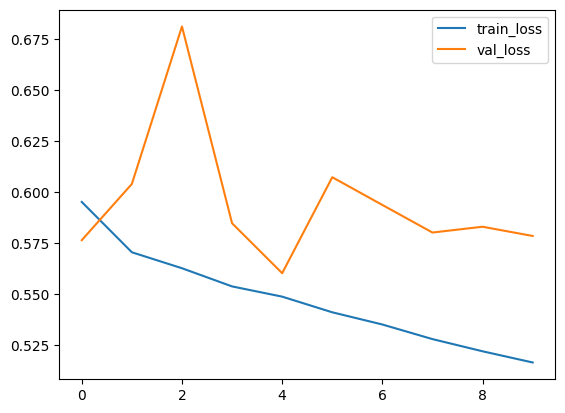

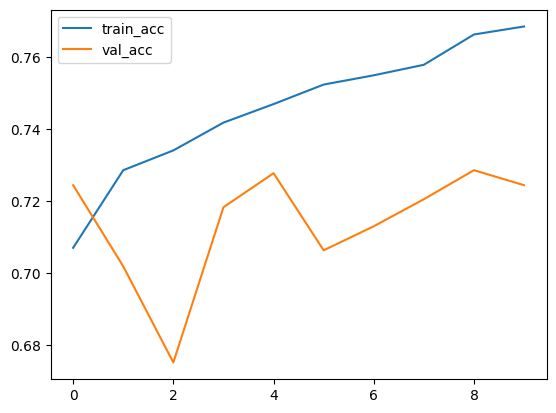

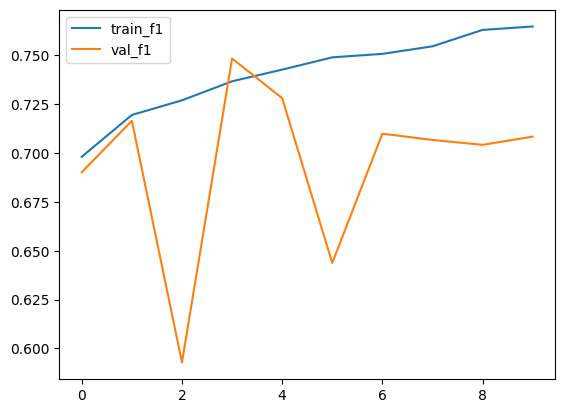

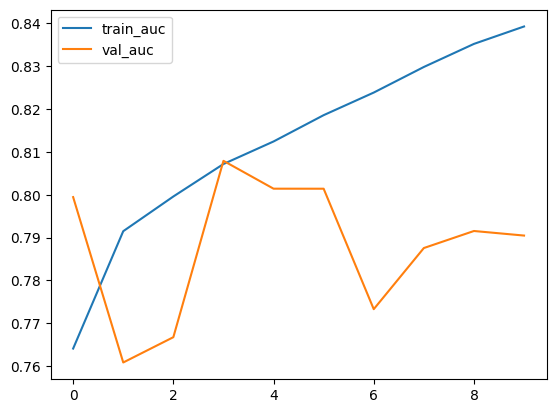

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_f1"], label="train_f1")
plt.plot(history["val_f1"], label="val_f1")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_auc"], label="train_auc")
plt.plot(history["val_auc"], label="val_auc")
plt.legend()
plt.show()
